# Random Forest (EDA-9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import joblib

## Import data

In [2]:
# Reading data
X_train = pd.read_csv('../../data/processed/X_train_eda9.csv')
X_test = pd.read_csv('../../data/processed/X_test_eda9.csv')
y_train = pd.read_csv('../../data/processed/y_train_eda9.csv')
y_test = pd.read_csv('../../data/processed/y_test_eda9.csv')

## Creating model and training data - Random Forest

In [3]:
# Initialize random forest model
random_model = RandomForestClassifier(random_state=18, 
                                   class_weight='balanced')

# Train the model
random_model.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KeyboardInterrupt: 

## Predictions

In [ ]:
# Make predictions on the test set
y_pred = random_model.predict(X_test)
y_probs = random_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_probs)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [ ]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5054874734830554,
 0.5111682082905105,
 0.5170400401961294,
 0.5140873579851332,
 0.5075849833249777)

In [ ]:
# Showing classification report
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.499533,0.493657,0.496578,56361.000000
1.0,0.511168,0.517040,0.514087,57717.000000
accuracy,0.505487,0.505487,0.505487,0.505487
macro avg,0.505351,0.505349,0.505333,114078.000000
weighted avg,0.505420,0.505487,0.505437,114078.000000


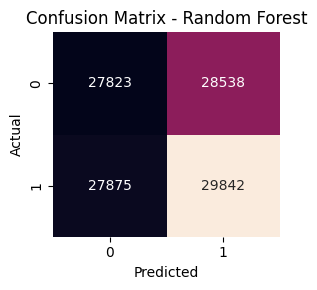

In [ ]:
# Plotting confussion matrix
cm1 = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm1)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.tight_layout()
plt.show()

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [None, 10, 20, 30],
              'min_samples_leaf': [50, 100, 200],
              'max_features': ['sqrt', 'log2'],
              'bootstrap': [True]}


# Initialize the random search
random_search = RandomizedSearchCV(estimator=random_model,
                                   param_distributions=hyperparams,
                                   n_iter=20,
                                   cv=5, 
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   verbose=1,
                                   random_state=18)

# Train with original data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestC...ndom_state=18)
,param_distributions,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [50, 100, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,18
,error_score,nan


In [ ]:
# Best parameters and evaluation
best_random_model = random_search.best_estimator_

y_pred_hiper = best_random_model.predict(X_test)
y_probs_hiper = best_random_model.predict_proba(X_test)[:, 1]

In [ ]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_hiper)
test_precision = precision_score(y_test, y_pred_hiper)
test_recall = recall_score(y_test, y_pred_hiper)
test_f1 = f1_score(y_test, y_pred_hiper)
test_roc_auc = roc_auc_score(y_test, y_probs_hiper)

In [ ]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5085906134399271,
 0.5157084928184333,
 0.47154217994698266,
 0.4926374093817596,
 0.5153436176220169)

In [ ]:
# Showing classification report
report_dict2 = classification_report(y_test, y_pred_hiper, output_dict=True)
df_report2 = pd.DataFrame(report_dict).transpose()
df_report2

,precision,recall,f1-score,support
0.0,0.499533,0.493657,0.496578,56361.000000
1.0,0.511168,0.517040,0.514087,57717.000000
accuracy,0.505487,0.505487,0.505487,0.505487
macro avg,0.505351,0.505349,0.505333,114078.000000
weighted avg,0.505420,0.505487,0.505437,114078.000000


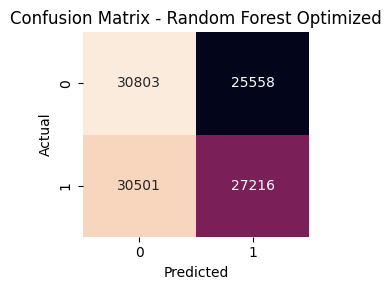

In [ ]:
# Plotting confussion matrix
bank_cm = confusion_matrix(y_test, y_pred_hiper)
df_cm = pd.DataFrame(bank_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.title('Confusion Matrix - Random Forest Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Save model

In [ ]:
# Saving best model
joblib.dump(best_random_model, '../../models/random-forest-model-final.pkl')

['../../models/random-forest-model-final.pkl']